 # PART 2: WIND POWER

In [26]:
#Load data from csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns       
load_file_w = pd.read_csv('wind_student.csv',sep=',',index_col=0,parse_dates=True)
load_file_w.index = pd.to_datetime(load_file_w.index, utc=True).tz_convert("Europe/Berlin")
load_file_w.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26280 entries, 2013-01-01 01:00:00+01:00 to 2016-01-01 00:00:00+01:00
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Simulation  26280 non-null  float64
 1   Actuals     26280 non-null  float64
dtypes: float64(2)
memory usage: 615.9 KB


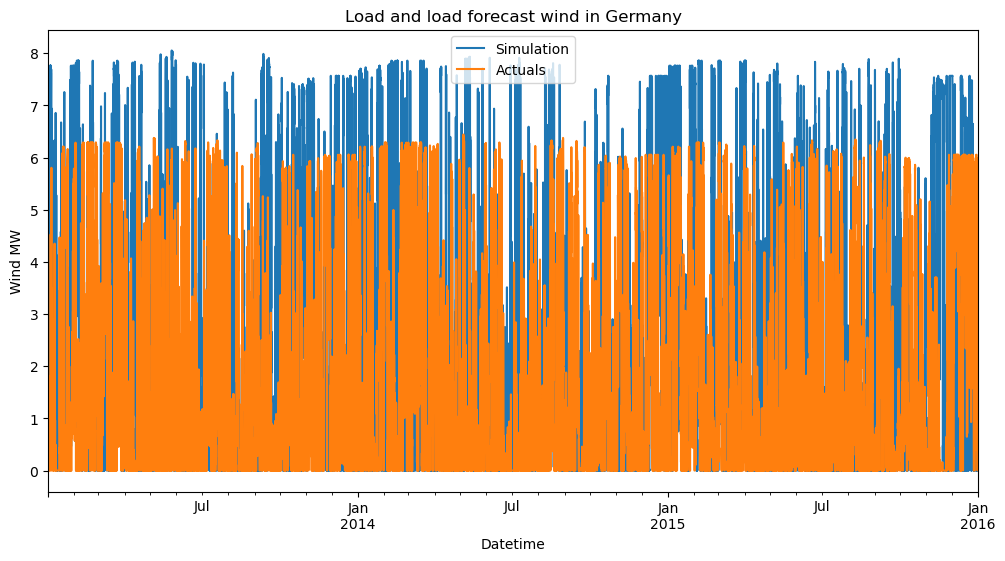

In [2]:
load_file_w.plot(title='Load and load forecast wind in Germany',
                     figsize=(12,6),
                     ylabel='Wind MW');

In [3]:
# =========================
#  have a quick look at the data
# =========================
print(load_file_w.head(10))
print(load_file_w.tail(10))

load_file_w["Simulation"].describe()
load_file_w["Actuals"].describe()

                           Simulation   Actuals
Datetime                                       
2013-01-01 01:00:00+01:00     7.08690  0.635242
2013-01-01 02:00:00+01:00     1.87143  0.714658
2013-01-01 03:00:00+01:00     4.61316  2.397256
2013-01-01 04:00:00+01:00     5.39293  3.998696
2013-01-01 05:00:00+01:00     5.81613  3.634848
2013-01-01 06:00:00+01:00     5.83240  3.980128
2013-01-01 07:00:00+01:00     7.55665  4.527072
2013-01-01 08:00:00+01:00     7.39710  3.112080
2013-01-01 09:00:00+01:00     7.09215  2.453320
2013-01-01 10:00:00+01:00     6.59084  2.453928
                           Simulation   Actuals
Datetime                                       
2015-12-31 15:00:00+01:00    0.496808  5.654528
2015-12-31 16:00:00+01:00    0.233307  5.119728
2015-12-31 17:00:00+01:00    0.000000  4.721256
2015-12-31 18:00:00+01:00    0.000000  5.717592
2015-12-31 19:00:00+01:00    0.000000  5.382696
2015-12-31 20:00:00+01:00    0.000000  5.983528
2015-12-31 21:00:00+01:00    0.000000  5

count    26280.000000
mean         1.587133
std          1.991928
min          0.000000
25%          0.000000
50%          0.671294
75%          2.480148
max          6.440800
Name: Actuals, dtype: float64

In [6]:
# Make working copy

df_w = pd.read_csv('wind_student.csv', sep=',', parse_dates=["Datetime"])
df_w = df_w.set_index("Datetime")
df_w.index = pd.to_datetime(df_w.index, utc=True).tz_convert("Europe/Berlin")

# =========================
# Construct error series
# =========================
df_w["error"] = df_w["Simulation"] - df_w["Actuals"]

print(df_w["error"].head(10))

Datetime
2013-01-01 01:00:00+01:00    6.451658
2013-01-01 02:00:00+01:00    1.156772
2013-01-01 03:00:00+01:00    2.215904
2013-01-01 04:00:00+01:00    1.394234
2013-01-01 05:00:00+01:00    2.181282
2013-01-01 06:00:00+01:00    1.852272
2013-01-01 07:00:00+01:00    3.029578
2013-01-01 08:00:00+01:00    4.285020
2013-01-01 09:00:00+01:00    4.638830
2013-01-01 10:00:00+01:00    4.136912
Name: error, dtype: float64


In [7]:
# =========================
#  Comprehensive sanity checks
# =========================
print("=" * 60)
print("1. Data shape")
print(df_w.shape)

print("\n2. Time range")
print(df_w.index.min())
print(df_w.index.max())

print("\n3. Missing values")
print(df_w.isna().sum())

print("\n4. Daily observations")
print(df_w.groupby(df_w.index.date).size().value_counts().sort_index())

print("\n5. Timezone")
print(df_w.index.tz)


print("\n6. Value range reasonableness")
print(df_w.describe())


print("\n8. Duplicate timestamps")
print(f"Number of duplicate timestamps: {df_w.index.duplicated().sum()}")

1. Data shape
(26280, 3)

2. Time range
2013-01-01 01:00:00+01:00
2016-01-01 00:00:00+01:00

3. Missing values
Simulation    0
Actuals       0
error         0
dtype: int64

4. Daily observations
1        1
23       4
24    1088
25       3
Name: count, dtype: int64

5. Timezone
Europe/Berlin

6. Value range reasonableness
         Simulation       Actuals         error
count  26280.000000  26280.000000  26280.000000
mean       1.894674      1.587133      0.307541
std        2.442843      1.991928      3.092791
min        0.000000      0.000000     -6.440800
25%        0.000000      0.000000     -1.255440
50%        0.784415      0.671294      0.000000
75%        2.837682      2.480148      1.680359
max        8.051000      6.440800      7.951400

8. Duplicate timestamps
Number of duplicate timestamps: 0


Daily MAE summary:
count    1096.000000
mean        2.224728
std         1.604064
min         0.000000
25%         0.973474
50%         1.839336
75%         3.143074
max         7.770179
Name: error, dtype: float64

Top 10 largest daily MAE:
2013-02-04    7.770179
2015-03-29    7.720937
2015-11-18    7.407305
2015-11-29    7.391253
2015-11-19    7.385918
2014-12-22    7.368203
2015-01-10    7.355301
2013-10-28    7.154534
2013-02-05    7.128406
2015-11-17    7.050084
Name: error, dtype: float64


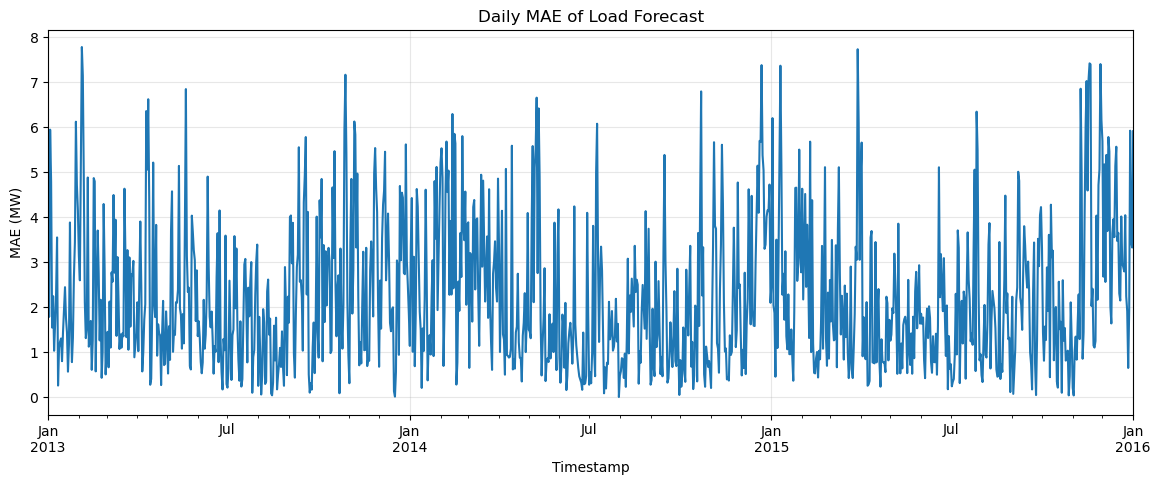

In [9]:
# =========================
# Daily MAE
# =========================
daily_mae = df_w.groupby(df_w.index.date)["error"].apply(lambda x: x.abs().mean())
daily_mae.index = pd.to_datetime(daily_mae.index)
daily_mae = daily_mae.dropna()


print("Daily MAE summary:")
print(daily_mae.describe())

print("\nTop 10 largest daily MAE:")
print(daily_mae.nlargest(10))

# =========================
#  Plot daily MAE
# =========================
plt.figure(figsize=(14, 5))
daily_mae.plot()
plt.title("Daily MAE of Load Forecast")
plt.ylabel("MAE (MW)")
plt.xlabel("Timestamp")
plt.grid(True, alpha=0.3)
plt.show()

Mean error (bias): 0.3075
Mean absolute error（MAE）: 2.2213


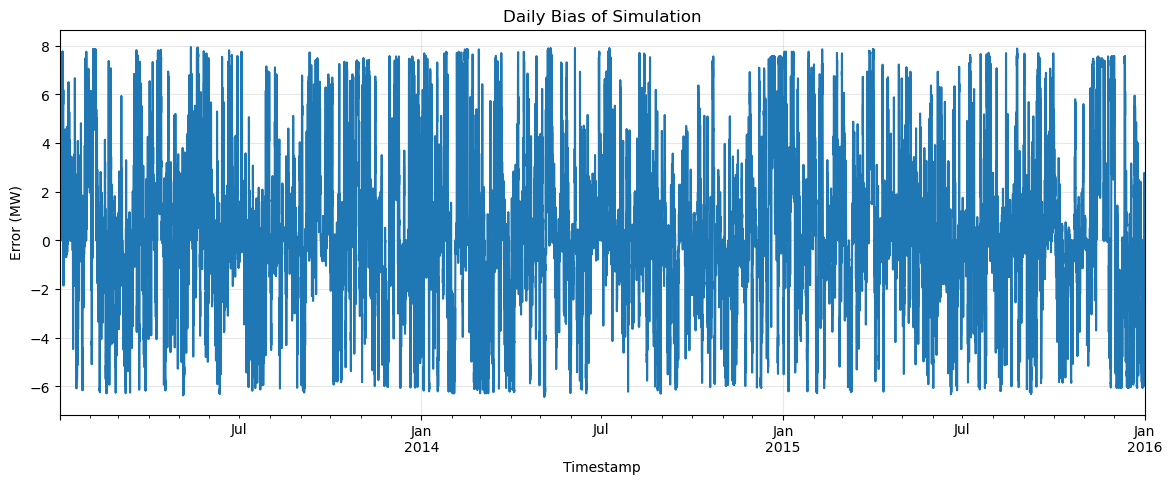

Error volatility diagnostics
Standard deviation of error: 3.0928
Variance of error: 9.5654
MAPE: 354.30%
RMSE: 3.1080 MW


In [13]:
# =========================
#  daily bias 
# =========================
daily_bias = df_w.groupby(df_w.index.date)["error"].mean()
daily_bias.index = pd.to_datetime(daily_bias.index)
daily_bias = daily_bias.dropna()


mean_error = df_w["error"].mean()
mean_abs_error = df_w["error"].abs().mean()


print(f"Mean error (bias): {mean_error:.4f}")
print(f"Mean absolute error（MAE）: {mean_abs_error:.4f}")

plt.figure(figsize=(14, 5))
df_w["error"].plot()
plt.title("Daily Bias of Simulation")
plt.ylabel("Error (MW)")
plt.xlabel("Timestamp")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
#  Error volatility
# =========================
print("Error volatility diagnostics")
print(f"Standard deviation of error: {df_w['error'].std():.4f}")
print(f"Variance of error: {df_w['error'].var():.4f}")

# =========================
#  MAPE and RMSE
# =========================
#for only cells where actuals are higher than zero, in daytime hours
nz_actuals= df_w["Actuals"]> 0.01
mape = (df_w['error'].abs() / df_w.loc[nz_actuals, "Actuals"]).mean() * 100 
print(f"MAPE: {mape:.2f}%")

rmse = np.sqrt((df_w['error'] ** 2).mean())
print(f"RMSE: {rmse:.4f} MW")

In [14]:
# To observe the MAPE by hours per day to find weaknesses
df_analysis = df_w.loc[nz_actuals].copy()
df_analysis["rel_error"] = (df_analysis["error"].abs() / df_analysis["Actuals"]) * 100
df_analysis["hour"] = df_analysis.index.hour
print("MAPE by hours per day:")
print(df_analysis.groupby("hour")["rel_error"].mean().round(1))

MAPE by hours per day:
hour
0     328.8
1     380.4
2     386.1
3     322.9
4     300.9
5     313.9
6     413.4
7     378.4
8     262.3
9     403.1
10    290.1
11    347.3
12    465.3
13    381.6
14    311.1
15    300.9
16    345.9
17    261.1
18    307.7
19    572.5
20    319.0
21    292.8
22    393.8
23    411.1
Name: rel_error, dtype: float64


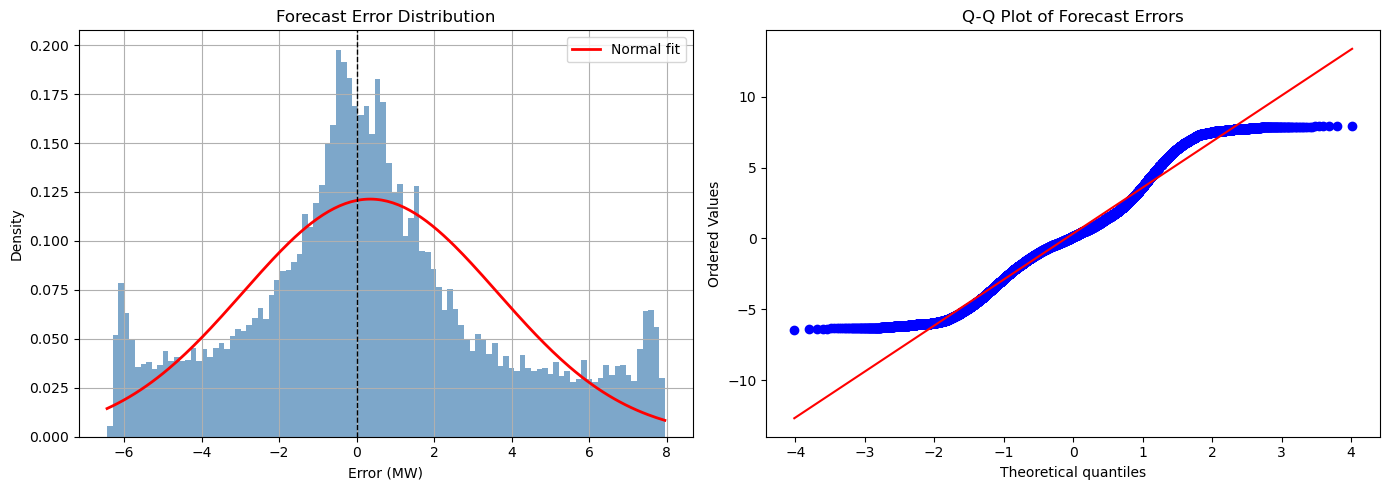

Skewness: 0.2660
Kurtosis: -0.1659


In [16]:
# =========================
#  error distribution analysis
# =========================
import scipy.stats as stats

#Let´s filter only with hours with real generation
nz_values = (df_w["Actuals"] > 0.01) | (df_w["Simulation"] > 0.01)
df_wind = df_w[nz_values].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram + normal fit
ax1 = axes[0]
df_wind['error'].hist(bins=100, ax=ax1, density=True, alpha=0.7, color='steelblue')
mu, std = stats.norm.fit(df_wind['error'])
x = np.linspace(df_wind['error'].min(), df_wind['error'].max(), 200)
ax1.plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Normal fit')
ax1.axvline(0, color='black', linestyle='--', linewidth=1)
ax1.set_title('Forecast Error Distribution')
ax1.set_xlabel('Error (MW)')
ax1.set_ylabel('Density')
ax1.legend()

# ：QQ plot
ax2 = axes[1]
stats.probplot(df_wind['error'], dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot of Forecast Errors')

plt.tight_layout()
plt.show()

# statistics on raw error(15min intervals)
print(f"Skewness: {df_wind['error'].skew():.4f}")
print(f"Kurtosis: {df_wind['error'].kurtosis():.4f}")

<Figure size 1200x500 with 0 Axes>

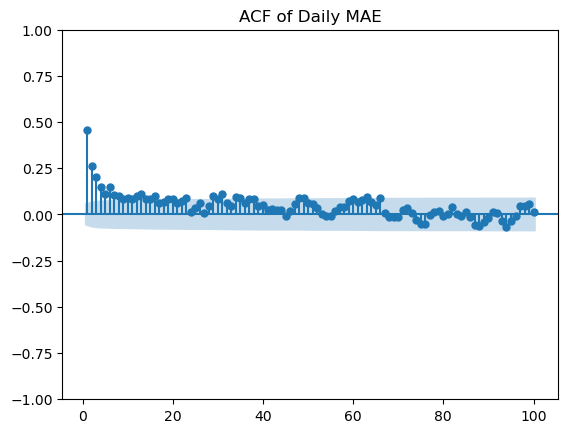

    lb_stat  lb_pvalue
7  4.27e+02   3.91e-88
14 4.96e+02   7.10e-97
20 5.40e+02  1.35e-101


In [17]:
# =========================
# Autocorrelation check
# =========================

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.figure(figsize=(12, 5))
plot_acf(daily_mae, lags=100,zero = False)
plt.title("ACF of Daily MAE")
plt.show()


pd.set_option('display.float_format', '{:.2e}'.format)
result = acorr_ljungbox(daily_mae, lags=[7, 14, 20], return_df=True)
print(result)

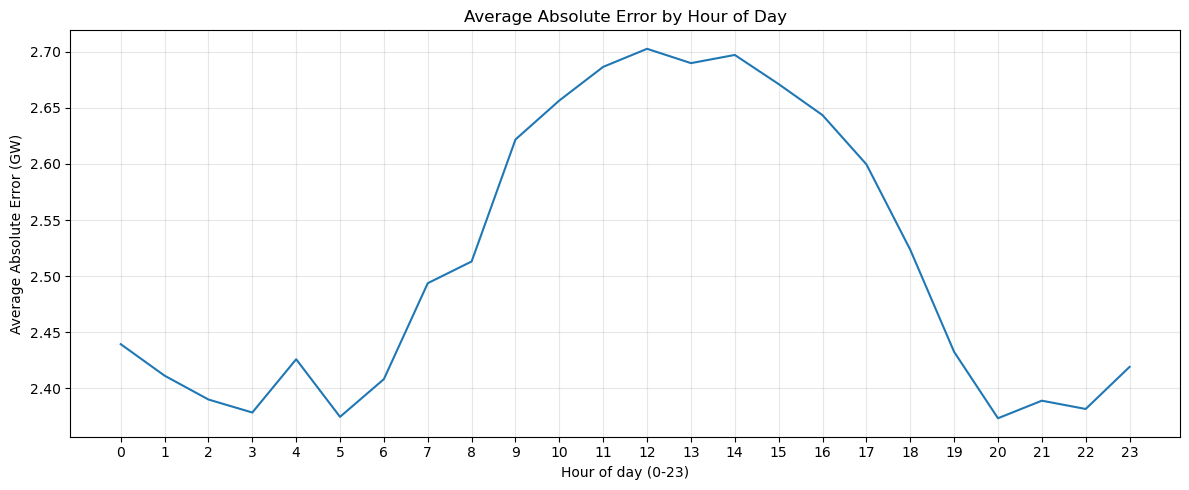

In [18]:
# =========================
#  Intraday error pattern
# =========================
intraday_slot = df_wind.index.hour
intraday_mae = df_wind.groupby(intraday_slot)["error"].apply(lambda x: x.abs().mean())

plt.figure(figsize=(12, 5))
intraday_mae.plot()
plt.title("Average Absolute Error by Hour of Day")
plt.xlabel("Hour of day (0-23)")
plt.ylabel("Average Absolute Error (GW)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# =========================
# yearly statistics table
# =========================

yearly_stats = df_wind.groupby(df_wind.index.year).apply(
    lambda x: pd.Series({
        'MAE': x['error'].abs().mean(),
        'RMSE': np.sqrt((x['error']**2).mean()),
        'Bias': x['error'].mean(),
        'MAPE (%)': (x.loc[x['Actuals'] > 0.05, 'error'].abs() / 
                     x.loc[x['Actuals'] > 0.05, 'Actuals']).mean() * 100,
        'RMSE/MAE': np.sqrt((x['error']**2).mean()) / x['error'].abs().mean()
    })
)

yearly_stats['RMSE/MAE'] = yearly_stats['RMSE'] / yearly_stats['MAE']
pd.set_option('display.float_format', '{:.3f}'.format)
print(yearly_stats.round(3))

print()

# =========================
# kruskal-wallis test for yearly MAE
# =========================

from scipy.stats import kruskal

mae_2015 = daily_mae[daily_mae.index.year == 2015]
mae_2016 = daily_mae[daily_mae.index.year == 2016]

stat, p = kruskal(mae_2015, mae_2016)

print(f"Kruskal-Wallis Test (2015 vs 2016)")
print(f"  H-statistic: {stat:.3f}")
print(f"  p-value:     {p:.3f}")
print(f"  Conclusion:  {'Significant difference between years (p < 0.05)' if p < 0.05 else 'No significant difference between years (p >= 0.05)'}")

           MAE  RMSE   Bias  MAPE (%)  RMSE/MAE
Datetime                                       
2013     2.521 3.289  0.557   262.755     1.304
2014     2.505 3.314  0.203   229.644     1.323
2015     2.511 3.314  0.280   214.968     1.320
2016     5.902 5.902 -5.902   100.000     1.000

Kruskal-Wallis Test (2015 vs 2016)
  H-statistic: 2.543
  p-value:     0.111
  Conclusion:  No significant difference between years (p >= 0.05)


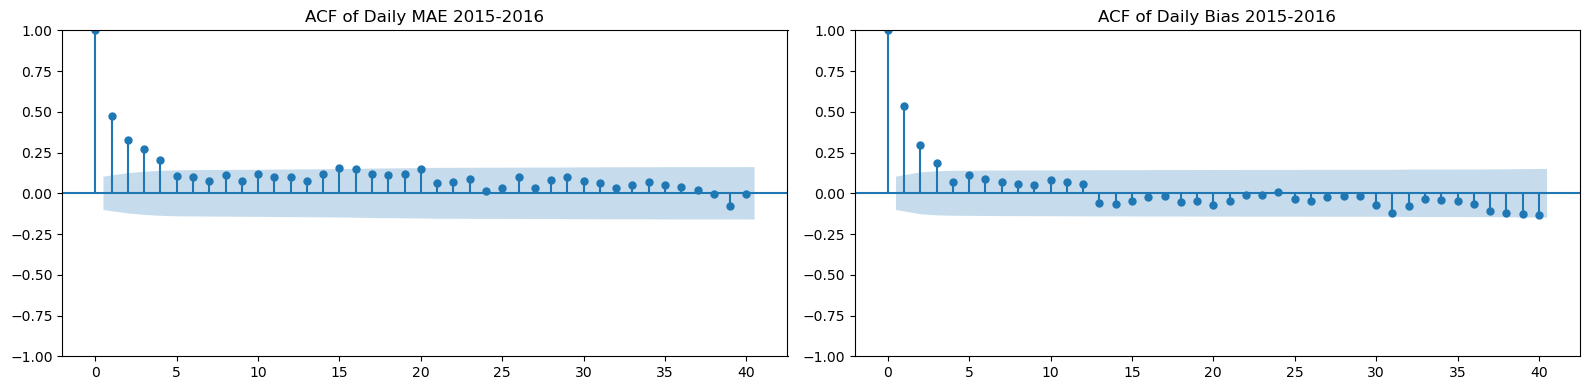

Ljung-Box test for stable period MAE
    lb_stat  lb_pvalue
7   176.559      0.000
14  204.739      0.000
20  246.856      0.000

Ljung-Box test for stable period Bias
    lb_stat  lb_pvalue
7   161.373      0.000
14  172.395      0.000
20  177.625      0.000


In [20]:
# =========================
#  stable period 2015-2016 examination
# =========================
 
stable_peroid_mae  = daily_mae['2015':'2016'].dropna()
stable_peroid_bias = daily_bias['2015':'2016'].dropna()

# 5 ACF / serial dependence

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(stable_peroid_mae, lags=40, ax=axes[0])
axes[0].set_title("ACF of Daily MAE 2015-2016")

plot_acf(stable_peroid_bias, lags=40, ax=axes[1])
axes[1].set_title("ACF of Daily Bias 2015-2016")

plt.tight_layout()
plt.show()

# Ljung-Box
lb_mae = acorr_ljungbox(stable_peroid_mae, lags=[7, 14, 20], return_df=True)
lb_bias = acorr_ljungbox(stable_peroid_bias, lags=[7, 14, 20], return_df=True)

print("Ljung-Box test for stable period MAE")
print(lb_mae)
print("\nLjung-Box test for stable period Bias")
print(lb_bias)

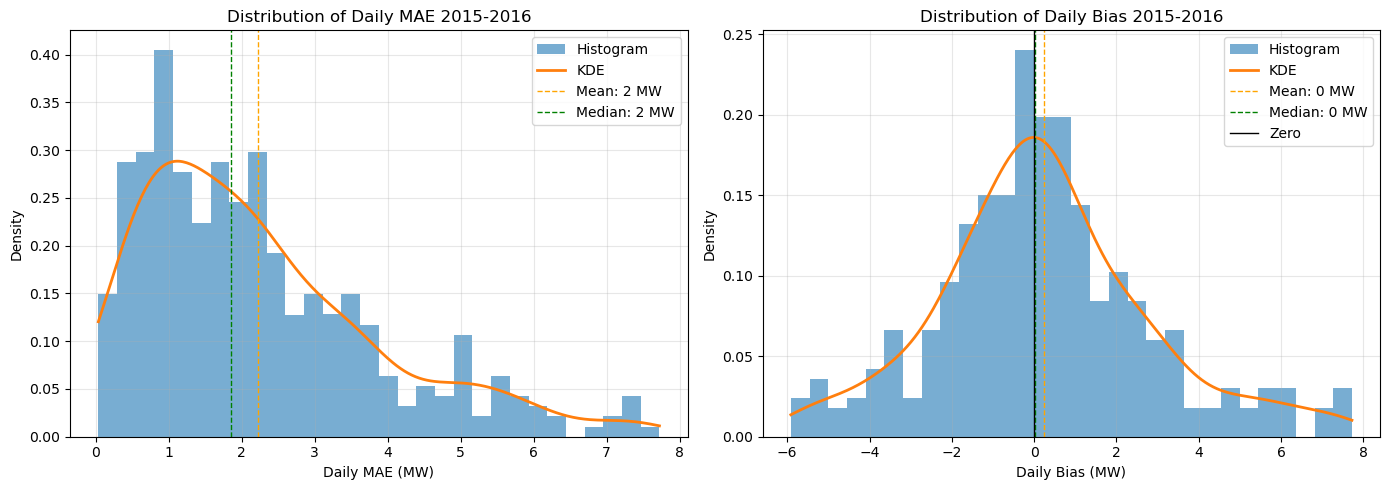

In [21]:
# =========================
# 2015-2016 error distribution of daily MAE and Bias
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- MAE Distribution ---
ax = axes[0]
ax.hist(stable_peroid_mae.dropna(), bins=30, density=True, alpha=0.6, label='Histogram')
kde = stats.gaussian_kde(stable_peroid_mae.dropna())
x = np.linspace(stable_peroid_mae.min(), stable_peroid_mae.max(), 300)
ax.plot(x, kde(x), linewidth=2, label='KDE')
ax.axvline(stable_peroid_mae.mean(), linestyle='--', color='orange', linewidth=1, label=f'Mean: {stable_peroid_mae.mean():.0f} MW')
ax.axvline(stable_peroid_mae.median(), linestyle='--', color='green', linewidth=1, label=f'Median: {stable_peroid_mae.median():.0f} MW')
ax.set_title("Distribution of Daily MAE 2015-2016")
ax.set_xlabel("Daily MAE (MW)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Bias Distribution ---
ax = axes[1]
ax.hist(stable_peroid_bias.dropna(), bins=30, density=True, alpha=0.6, label='Histogram')
kde = stats.gaussian_kde(stable_peroid_bias.dropna())
x = np.linspace(stable_peroid_bias.min(), stable_peroid_bias.max(), 300)
ax.plot(x, kde(x), linewidth=2, label='KDE')
ax.axvline(stable_peroid_bias.mean(), linestyle='--', color='orange', linewidth=1, label=f'Mean: {stable_peroid_bias.mean():.0f} MW')
ax.axvline(stable_peroid_bias.median(), linestyle='--', color='green', linewidth=1, label=f'Median: {stable_peroid_bias.median():.0f} MW')
ax.axvline(0, linestyle='-', color='black', linewidth=1, label='Zero')
ax.set_title("Distribution of Daily Bias 2015-2016")
ax.set_xlabel("Daily Bias (MW)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Skewness and kurtosis for stable period MAE and Bias
from scipy.stats import skew, kurtosis

print("Stable Period MAE skewness :", skew(stable_peroid_mae))
print("Stable Period MAE kurtosis :", kurtosis(stable_peroid_mae, fisher=True))

print("Stable Period Bias skewness:", skew(stable_peroid_bias))
print("Stable Period Bias kurtosis:", kurtosis(stable_peroid_bias, fisher=True))

Stable Period MAE skewness : 1.1126177613661177
Stable Period MAE kurtosis : 0.8161442235695495
Stable Period Bias skewness: 0.3739461352083116
Stable Period Bias kurtosis: 0.5300853922223068


In [23]:
# =========================
#  Yearly  and Quarterly summary table 2015-2016
# =========================
import pandas as pd

stable_peroid_df = pd.DataFrame({
    "MAE": stable_peroid_mae,
    "Bias": stable_peroid_bias
})

pd.set_option('display.float_format', '{:.3f}'.format)
# Annual statistics
stable_peroid_df["Year"] = stable_peroid_df.index.year
print("=== Annual Summary ===")
print(stable_peroid_df.groupby("Year")[["MAE", "Bias"]].agg(["mean", "median", "std"]).round(1))
print()

# Quarterly statistics (appendix)
stable_peroid_df["Quarter"] = stable_peroid_df.index.to_period("Q")
print("=== Quarterly Summary ===")
print(stable_peroid_df.groupby("Quarter")[["MAE", "Bias"]].agg(["mean", "std"]).round(1))

=== Annual Summary ===
       MAE                Bias             
      mean median   std   mean median   std
Year                                       
2015 2.200  1.800 1.600  0.200  0.000 2.600
2016 5.900  5.900   NaN -5.900 -5.900   NaN

=== Quarterly Summary ===
          MAE         Bias      
         mean   std   mean   std
Quarter                         
2015Q1  2.400 1.700  0.800 2.700
2015Q2  1.600 1.100  0.200 1.700
2015Q3  2.000 1.400  0.200 2.200
2015Q4  2.900 2.000 -0.200 3.300
2016Q1  5.900   NaN -5.900   NaN


In [24]:
# =========================
#  seasonal summary table 2013-2015
# =========================

#  Assign season labels

def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

season_order = ["Winter", "Spring", "Summer", "Autumn"]

stable_peroid_df["Month"] = stable_peroid_df.index.month
stable_peroid_df["Season"] = stable_peroid_df["Month"].apply(month_to_season)
stable_peroid_df["Season"] = pd.Categorical(
    stable_peroid_df["Season"],
    categories=season_order,
    ordered=True
)

# -----------------------------
#  Seasonal summary table
# -----------------------------
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

seasonal_summary = stable_peroid_df.groupby("Season", observed=False)[["MAE", "Bias"]].agg(
    ["mean", "median", "std", iqr]
)

print("Seasonal summary table:")
print(seasonal_summary)


# -----------------------------
# 5. Kruskal–Wallis tests
# -----------------------------
mae_groups = [
    stable_peroid_df.loc[stable_peroid_df["Season"] == s, "MAE"].dropna()
    for s in season_order
]
bias_groups = [
    stable_peroid_df.loc[stable_peroid_df["Season"] == s, "Bias"].dropna()
    for s in season_order
]

kw_mae = kruskal(*mae_groups)
kw_bias = kruskal(*bias_groups)

print("\nKruskal–Wallis test for MAE across seasons:")
print(kw_mae)

print("\nKruskal–Wallis test for Bias across seasons:")
print(kw_bias)

Seasonal summary table:
         MAE                      Bias                   
        mean median   std   iqr   mean median   std   iqr
Season                                                   
Winter 2.884  2.672 1.689 2.551 -0.217 -0.339 3.137 3.952
Spring 1.865  1.605 1.374 1.679  0.536  0.361 2.131 2.392
Summer 1.723  1.526 1.261 1.455 -0.122 -0.060 1.877 1.802
Autumn 2.453  2.044 1.914 2.356  0.729  0.017 2.902 3.531

Kruskal–Wallis test for MAE across seasons:
KruskalResult(statistic=np.float64(29.585313060607405), pvalue=np.float64(1.6869708754867731e-06))

Kruskal–Wallis test for Bias across seasons:
KruskalResult(statistic=np.float64(7.717849826289921), pvalue=np.float64(0.052217404709768184))


YEARLY SUMMARY (2015–2016)
       MAE                      Bias                   
      mean median   std   iqr   mean median   std   iqr
Year                                                   
2015 2.200  1.800 1.600 2.100  0.200  0.000 2.600 2.900
2016 5.900  5.900   NaN 0.000 -5.900 -5.900   NaN 0.000

SEASONAL SUMMARY (2015–2016)
         MAE                      Bias                   
        mean median   std   iqr   mean median   std   iqr
Season                                                   
Winter 2.900  2.700 1.700 2.600 -0.200 -0.300 3.100 4.000
Spring 1.900  1.600 1.400 1.700  0.500  0.400 2.100 2.400
Summer 1.700  1.500 1.300 1.500 -0.100 -0.100 1.900 1.800
Autumn 2.500  2.000 1.900 2.400  0.700  0.000 2.900 3.500

BIAS SIGN BY SEASON
        Mean (MW)  Median (MW)  % Days Positive  % Days Negative
Season                                                          
Winter     -0.200       -0.300           47.300           52.700
Spring      0.500        0.400           

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23716\3775688155.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal = baseline_df.groupby("Season")[["MAE", "Bias"]].agg(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_23716\3775688155.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sign_table = baseline_df.groupby("Season")["Bias"].agg(


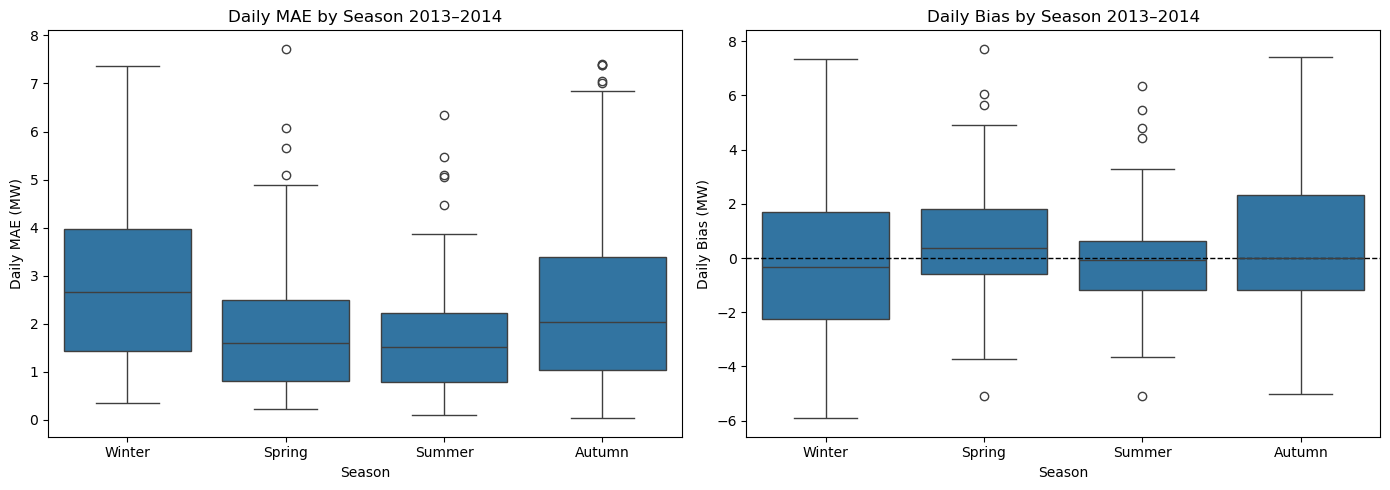

In [27]:
# =========================
# examnation of  2015-2016 
# =========================

# ─── 1.  Phase I baseline: 2015–2016 ───────────────────────
baseline_mae = daily_mae.loc['2015-01-01':'2016-12-31']
baseline_bias = daily_bias.loc['2015-01-01':'2016-12-31']

# ─── 2.  DataFrame ──────────────────────────────────────────
baseline_df = pd.DataFrame({
    "MAE": baseline_mae,
    "Bias": baseline_bias
}).copy()

baseline_df = baseline_df.dropna(subset=["MAE", "Bias"]).copy()


baseline_df["Year"] = baseline_df.index.year
baseline_df["Month"] = baseline_df.index.month
baseline_df["Season"] = baseline_df["Month"].apply(month_to_season)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
baseline_df["Season"] = pd.Categorical(
    baseline_df["Season"],
    categories=season_order,
    ordered=True
)

# ─── 3. IQR function ────────────────────────────────────────────
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

# ─── 4. Yearly Summary ──────────────────────────────────────────
print("=" * 60)
print("YEARLY SUMMARY (2015–2016)")
print("=" * 60)

yearly = baseline_df.groupby("Year")[["MAE", "Bias"]].agg(
    ["mean", "median", "std", iqr]
).round(1)
print(yearly)

# ─── 5. Seasonal Summary ────────────────────────────────────────
print("\n" + "=" * 60)
print("SEASONAL SUMMARY (2015–2016)")
print("=" * 60)

seasonal = baseline_df.groupby("Season")[["MAE", "Bias"]].agg(
    ["mean", "median", "std", iqr]
).round(1)
print(seasonal)

# ─── 6. Bias Sign Table ─────────────────────────────────────────
print("\n" + "=" * 60)
print("BIAS SIGN BY SEASON")
print("=" * 60)

sign_table = baseline_df.groupby("Season")["Bias"].agg(
    mean="mean",
    median="median",
    pct_pos=lambda x: (x > 0).mean() * 100,
    pct_neg=lambda x: (x < 0).mean() * 100,
).round(1)

sign_table.columns = ["Mean (MW)", "Median (MW)", "% Days Positive", "% Days Negative"]
print(sign_table)

# ─── 7. Kruskal–Wallis Tests ────────────────────────────────────
print("\n" + "=" * 60)
print("KRUSKAL–WALLIS TEST (2013–2014)")
print("=" * 60)

mae_groups = [
    baseline_df.loc[baseline_df["Season"] == s, "MAE"].dropna()
    for s in season_order
]
bias_groups = [
    baseline_df.loc[baseline_df["Season"] == s, "Bias"].dropna()
    for s in season_order
]

kw_mae = kruskal(*mae_groups)
kw_bias = kruskal(*bias_groups)

print(f"MAE  — H = {kw_mae.statistic:.3f}, p = {kw_mae.pvalue:.2e}")
print(f"Bias — H = {kw_bias.statistic:.3f}, p = {kw_bias.pvalue:.2e}")

# -----------------------------
# Boxplots by season
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=baseline_df, x="Season", y="MAE", order=season_order, ax=axes[0])
axes[0].set_title("Daily MAE by Season 2013–2014")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Daily MAE (MW)")

sns.boxplot(data=baseline_df, x="Season", y="Bias", order=season_order, ax=axes[1])
axes[1].set_title("Daily Bias by Season 2013–2014")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Daily Bias (MW)")
axes[1].axhline(0, linestyle="--", linewidth=1, color="black")
plt.savefig("boxplot_season.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


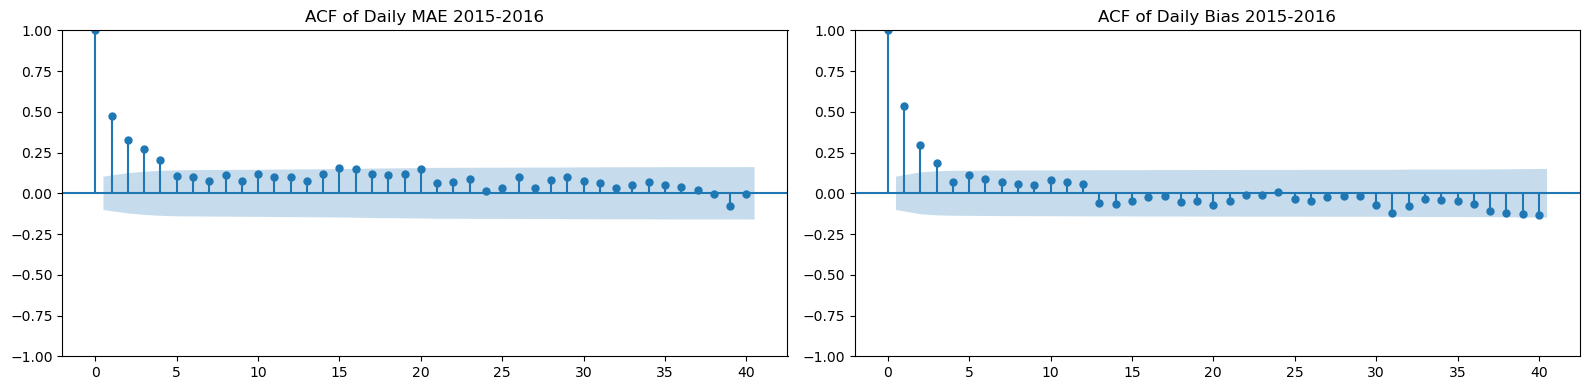

Ljung-Box test for baseline MAE
    lb_stat  lb_pvalue
7   176.559      0.000
14  204.739      0.000
20  246.856      0.000

Ljung-Box test for baseline Bias
    lb_stat  lb_pvalue
7   161.373      0.000
14  172.395      0.000
20  177.625      0.000


In [29]:
#  ACF / serial dependence baseline 2015–2016

baseline_mae = daily_mae.loc['2015-01-01':'2016-12-31'].dropna()
baseline_bias = daily_bias.loc['2015-01-01':'2016-12-31'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(baseline_mae, lags=40, ax=axes[0])
axes[0].set_title("ACF of Daily MAE 2015-2016")

plot_acf(baseline_bias, lags=40, ax=axes[1])
axes[1].set_title("ACF of Daily Bias 2015-2016")

plt.tight_layout()
plt.show()

# Ljung-Box
lb_mae = acorr_ljungbox(baseline_mae, lags=[7, 14, 20], return_df=True)
lb_bias = acorr_ljungbox(baseline_bias, lags=[7, 14, 20], return_df=True)

print("Ljung-Box test for baseline MAE")
print(lb_mae)
print("\nLjung-Box test for baseline Bias")
print(lb_bias)